In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys, os

sys.path.insert(0, os.path.abspath('..'))

from environment import (
    GridWorldEnv,
    P, C,
    policy_eval,
    INV_ST,
    TERMINAL_STATE,
    N_STATES,
    N_ACTIONS,
    ACTION_DELTAS,
)

In [3]:
# local convenience: flat index -> (row, col)
def flat_to_rc(s: int) -> tuple[int, int]:
    return divmod(s, 8)

GRID_SIZE = 8
GAMMA     = 0.85

# pre-compute valid non-terminal mask once
inv_st_set   = set(INV_ST)
valid_mask   = np.ones(N_STATES, dtype=bool)
valid_mask[list(inv_st_set)]  = False
valid_mask[TERMINAL_STATE]    = False
valid_states = np.where(valid_mask)[0]

optimal = np.array([
    [4.4098, 3.8096, 3.8096, 3.8096, 3.8096, 4.4098, 4.9311, 5.3873],
    [4.4098,      0, 3.0288, 3.0288,      0, 4.4098, 4.9311, 5.3873],
    [4.8806,      0, 2.1455, 2.1455,      0, 5.0336, 5.0336, 5.4940],
    [5.2439,      0, 2.0294, 1.0000,      0,      0,      0, 5.1445],
    [4.9307,      0,      0, 1.0000,      0, 1.0000,      0, 4.7615],
    [4.4761, 4.4761,      0, 1.0000, 1.0000, 1.0000,      0, 4.3139],
    [4.3638, 3.7411,      0, 2.0988, 2.0988, 2.0988,      0, 3.7411],
    [4.3638, 3.7411, 3.0170, 3.0170, 3.0170, 3.0170, 3.0170, 3.7411],
])
optimal_flat = optimal.ravel()

print(f"Total states          : {N_STATES}")
print(f"Blocked states        : {len(INV_ST)}")
print(f"Terminal state        : flat index {TERMINAL_STATE}, (row=4, col=4)")
print(f"Valid non-terminal    : {len(valid_states)}")
print(f"State-action pairs    : {len(valid_states)} x {N_ACTIONS} = {len(valid_states)*N_ACTIONS}")
print(f"Discount gamma        : {GAMMA}")
print(f"Blocked flat indices  : {sorted(INV_ST)}")

Total states          : 64
Blocked states        : 15
Terminal state        : flat index 36, (row=4, col=4)
Valid non-terminal    : 48
State-action pairs    : 48 x 9 = 432
Discount gamma        : 0.85
Blocked flat indices  : [9, 12, 17, 20, 25, 28, 29, 30, 33, 34, 38, 42, 46, 50, 54]


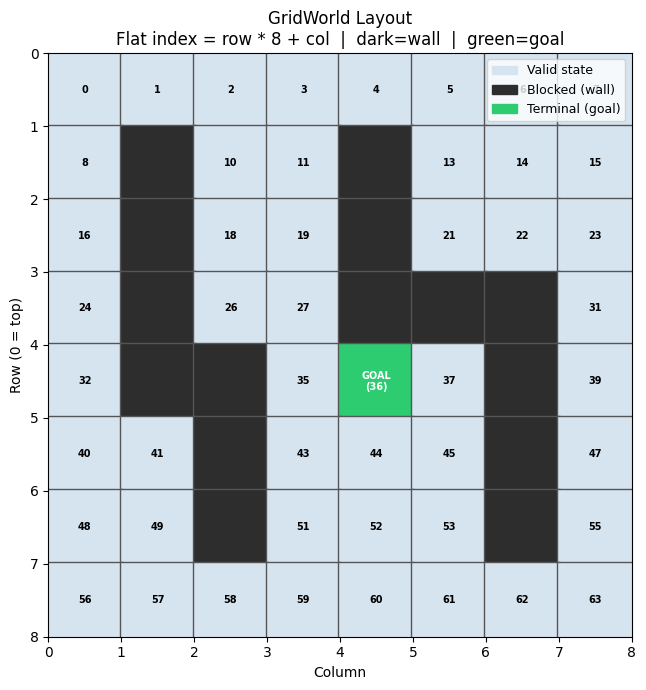

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

for s in range(N_STATES):
    row, col = flat_to_rc(s)
    if s in inv_st_set:
        color = '#2d2d2d'
    elif s == TERMINAL_STATE:
        color = '#2ecc71'
    else:
        color = '#d6e4f0'

    rect = mpatches.FancyBboxPatch(
        (col, GRID_SIZE - 1 - row), 1, 1,
        boxstyle="square,pad=0.02",
        linewidth=1, edgecolor='#555555', facecolor=color
    )
    ax.add_patch(rect)

    if s not in inv_st_set:
        label = f"{s}" if s != TERMINAL_STATE else f"GOAL\n({s})"
        ax.text(
            col + 0.5, GRID_SIZE - 1 - row + 0.5, label,
            ha='center', va='center', fontsize=7,
            color='black' if s != TERMINAL_STATE else 'white',
            fontweight='bold'
        )

ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)
ax.set_xticks(range(GRID_SIZE + 1))
ax.set_yticks(range(GRID_SIZE + 1))
ax.set_xticklabels(range(GRID_SIZE + 1))
ax.set_yticklabels(list(reversed(range(GRID_SIZE + 1))))
ax.set_xlabel("Column")
ax.set_ylabel("Row (0 = top)")
ax.set_title("GridWorld Layout\nFlat index = row * 8 + col  |  dark=wall  |  green=goal",
             fontsize=12)
ax.set_aspect('equal')
ax.grid(False)

legend_handles = [
    mpatches.Patch(color='#d6e4f0', label='Valid state'),
    mpatches.Patch(color='#2d2d2d', label='Blocked (wall)'),
    mpatches.Patch(color='#2ecc71', label='Terminal (goal)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('../report/figures/00/01_grid_layout.png', dpi=150, bbox_inches='tight')
plt.show()

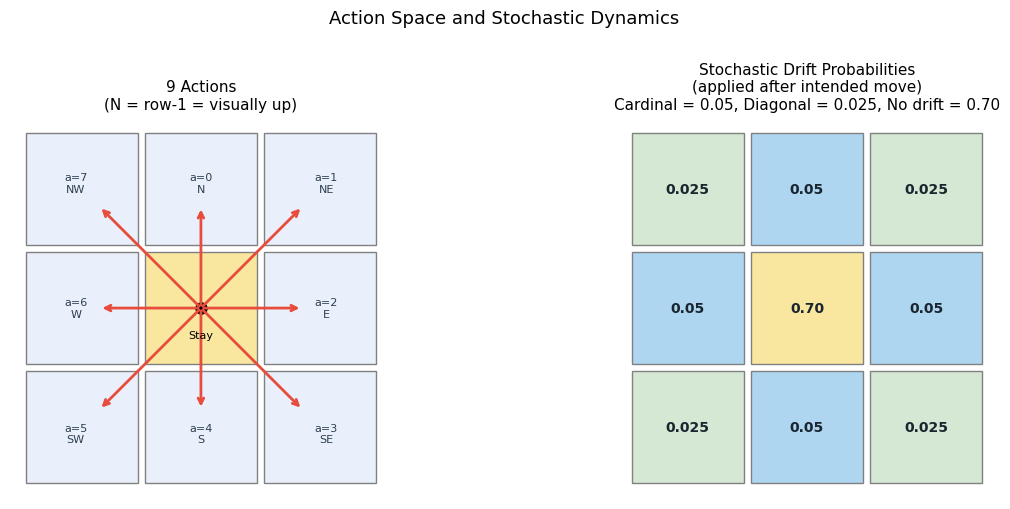

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Left: 9 action directions ----
ax = axes[0]
# ACTION_DELTAS uses (row_delta, col_delta)
# visually: col_delta = dx (right), -row_delta = dy (up)
action_plot = {
    idx: (label, dc, -dr)
    for idx, (dr, dc) in ACTION_DELTAS.items()
    for label in [['N','NE','E','SE','S','SW','W','NW','Stay'][idx]]
}

for dr_plot in [-1, 0, 1]:
    for dc_plot in [-1, 0, 1]:
        rect = mpatches.FancyBboxPatch(
            (dc_plot - 0.45, dr_plot - 0.45), 0.9, 0.9,
            boxstyle="square,pad=0.02",
            linewidth=1, edgecolor='gray',
            facecolor='#eaf0fb' if (dr_plot, dc_plot) != (0, 0) else '#f9e79f'
        )
        ax.add_patch(rect)

ARROW_SCALE = 0.85
for action_idx, (label, dx, dy) in action_plot.items():
    if (dx, dy) == (0, 0):
        ax.plot(0, 0, 'ko', markersize=8)
        ax.text(0, -0.18, label, ha='center', va='top', fontsize=8)
    else:
        ax.annotate(
            "", xy=(dx * ARROW_SCALE, dy * ARROW_SCALE), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2)
        )
        ax.text(dx * 1.05, dy * 1.05, f"a={action_idx}\n{label}",
                ha='center', va='center', fontsize=8, color='#2c3e50')

ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("9 Actions\n(N = row-1 = visually up)", fontsize=11)

# ---- Right: stochastic drift probabilities ----
ax = axes[1]
# displayed using same visual convention: x=col_delta, y=-row_delta
drift_layout = {
    (0,  0): ('0.70', '#f9e79f'),   # no drift
    (-1, 0): ('0.05', '#aed6f1'),   # N drift: row-1 -> y+1 visually
    ( 1, 0): ('0.05', '#aed6f1'),   # S drift
    (0, -1): ('0.05', '#aed6f1'),   # W drift
    (0,  1): ('0.05', '#aed6f1'),   # E drift
    (-1,-1): ('0.025','#d5e8d4'),
    (-1, 1): ('0.025','#d5e8d4'),
    ( 1,-1): ('0.025','#d5e8d4'),
    ( 1, 1): ('0.025','#d5e8d4'),
}
# key = (row_delta, col_delta); plot position: x=col_delta, y=-row_delta
for (dr, dc), (prob_str, color) in drift_layout.items():
    px, py = dc, -dr
    rect = mpatches.FancyBboxPatch(
        (px - 0.45, py - 0.45), 0.9, 0.9,
        boxstyle="square,pad=0.02",
        linewidth=1, edgecolor='gray', facecolor=color
    )
    ax.add_patch(rect)
    ax.text(px, py, prob_str, ha='center', va='center',
            fontsize=10, fontweight='bold', color='#1a252f')

ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(
    "Stochastic Drift Probabilities\n(applied after intended move)\n"
    "Cardinal = 0.05, Diagonal = 0.025, No drift = 0.70",
    fontsize=11
)

plt.suptitle("Action Space and Stochastic Dynamics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../report/figures/00/02_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print("=" * 55)
print("SANITY CHECK 1: P row sums for all valid (s, a) pairs")
print("=" * 55)

failures = []
checked  = 0

for s in valid_states:
    for a in range(N_ACTIONS):
        row_sum = P[:, s, a].sum()
        checked += 1
        if not np.isclose(row_sum, 1.0, atol=1e-9):
            failures.append((s, a, row_sum))

if failures:
    print(f"FAIL: {len(failures)} (s,a) pairs with P row sum != 1.0")
    for s, a, rs in failures[:10]:
        print(f"  s={s}, a={a}, sum={rs:.10f}")
else:
    print(f"PASS: all {checked} valid (s,a) pairs have P[:,s,a].sum() == 1.0")

print()
print("=" * 55)
print("SANITY CHECK 2: C matrix value ranges")
print("=" * 55)

nonzero_C = C[C > 0]
print(f"Non-zero entries in C : {len(nonzero_C)}")
print(f"Min non-zero C        : {nonzero_C.min():.4f}")
print(f"Max C                 : {C.max():.4f}")
print(f"Unique C values       : {np.unique(C.round(4))}")

print()
print("=" * 55)
print("SANITY CHECK 3: Terminal state is absorbing")
print("=" * 55)

for a in range(N_ACTIONS):
    p_self = P[TERMINAL_STATE, TERMINAL_STATE, a]
    assert np.isclose(p_self, 1.0, atol=1e-9), \
        f"FAIL: terminal not absorbing under action {a}, P={p_self}"
print(f"PASS: P[{TERMINAL_STATE},{TERMINAL_STATE},a] == 1.0 for all {N_ACTIONS} actions")

print()
print("=" * 55)
print("SANITY CHECK 4: Blocked states have zero outgoing probability")
print("=" * 55)

for s in INV_ST:
    for a in range(N_ACTIONS):
        total = P[:, s, a].sum()
        assert total == 0.0, \
            f"FAIL: blocked state s={s} has outgoing prob {total} under a={a}"
print(f"PASS: all {len(INV_ST)} blocked states have zero outgoing probability")

SANITY CHECK 1: P row sums for all valid (s, a) pairs
PASS: all 432 valid (s,a) pairs have P[:,s,a].sum() == 1.0

SANITY CHECK 2: C matrix value ranges
Non-zero entries in C : 2273
Min non-zero C        : 1.0000
Max C                 : 2.0000
Unique C values       : [0. 1. 2.]

SANITY CHECK 3: Terminal state is absorbing
PASS: P[36,36,a] == 1.0 for all 9 actions

SANITY CHECK 4: Blocked states have zero outgoing probability
PASS: all 15 blocked states have zero outgoing probability


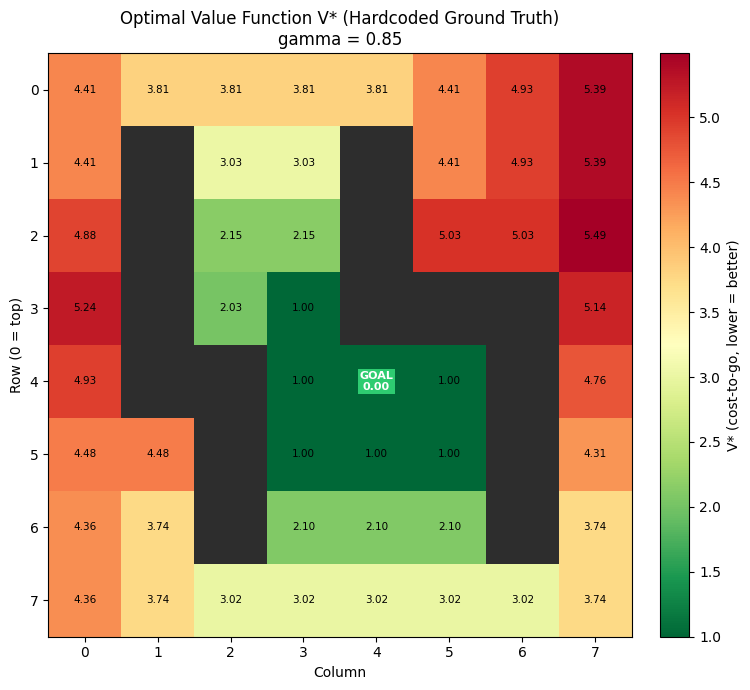

In [ ]:
optimal_display = optimal.copy().astype(float)
for s in INV_ST:
    r, c = flat_to_rc(s)
    optimal_display[r, c] = np.nan

tr, tc = flat_to_rc(TERMINAL_STATE)

fig, ax = plt.subplots(figsize=(8, 7))

cmap = plt.cm.RdYlGn_r.copy()
cmap.set_bad(color='#2d2d2d')

valid_vals = optimal_display[~np.isnan(optimal_display)]
valid_vals = valid_vals[valid_vals > 0]

im = ax.imshow(optimal_display, cmap=cmap, origin='upper',
               vmin=valid_vals.min(), vmax=valid_vals.max())

for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        s = r * GRID_SIZE + c
        if s in inv_st_set:
            continue
        if s == TERMINAL_STATE:
            ax.text(c, r, 'GOAL\n0.00', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold',
                    bbox=dict(facecolor='#2ecc71', edgecolor='none', pad=1))
        else:
            ax.text(c, r, f"{optimal_display[r, c]:.2f}",
                    ha='center', va='center', fontsize=7.5)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('V* (cost-to-go, lower = better)', fontsize=10)

ax.set_xticks(range(GRID_SIZE))
ax.set_yticks(range(GRID_SIZE))
ax.set_xticklabels(range(GRID_SIZE))
ax.set_yticklabels(range(GRID_SIZE))
ax.set_xlabel("Column")
ax.set_ylabel("Row (0 = top)")
ax.set_title("Optimal Value Function V* (Hardcoded Ground Truth)\ngamma = 0.85", fontsize=12)

plt.tight_layout()
plt.savefig('../report/figures/00/03_optimal_vstar_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Value iteration converged at iteration: 18

V_VI vs hardcoded V*:
  Max absolute difference : 0.000056
  Mean absolute difference: 0.000022
  All within 1e-2         : True


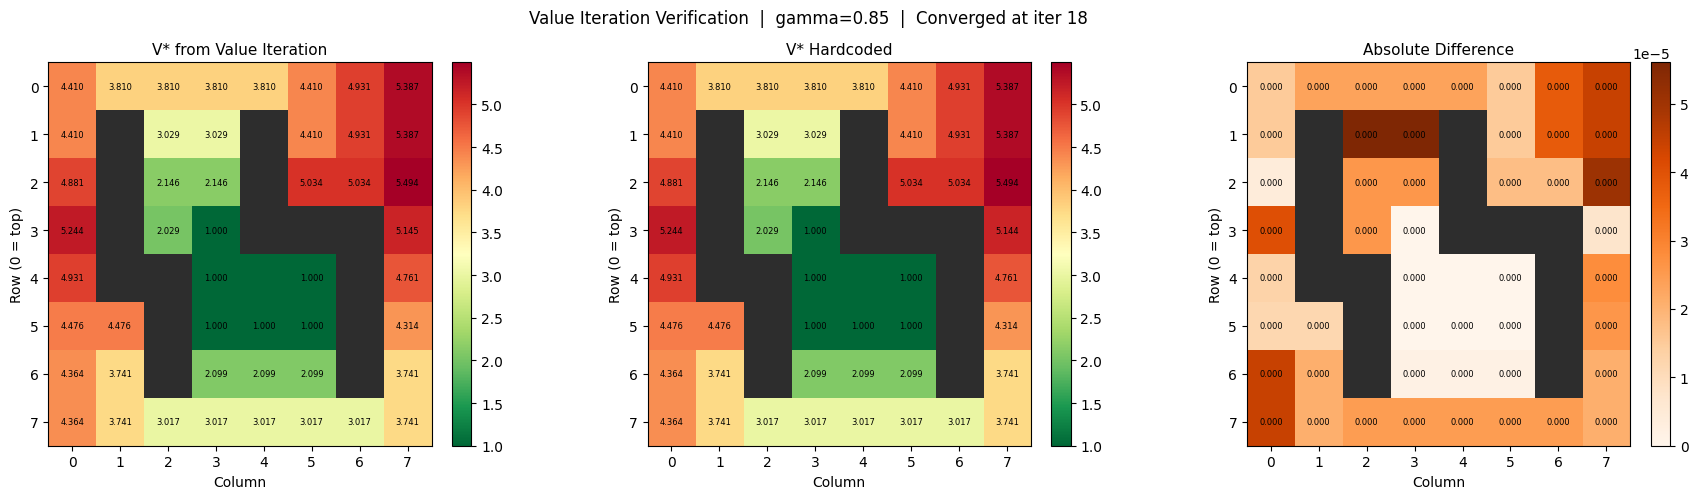

In [ ]:
def value_iteration(P, C, gamma=0.85, n_iter=2000, tol=1e-8):
    """
    V[s] = min_a  sum_{s'} P[s', s, a] * (C[s', s, a] + gamma * V[s'])
    """
    AvC = np.sum(P * C, axis=0)   # shape (64, 9): expected immediate cost
    V   = np.zeros(N_STATES)
    converged_at = n_iter

    for i in range(n_iter):
        V_old = V.copy()
        expected_next = np.einsum('ijk,i->jk', P, V)   # shape (64, 9)
        Q_vi_local = AvC + gamma * expected_next
        V_new = np.min(Q_vi_local, axis=1)

        V_new[list(inv_st_set)] = 0.0
        V_new[TERMINAL_STATE]   = 0.0

        V = V_new
        if np.max(np.abs(V - V_old)) < tol:
            converged_at = i + 1
            break

    return V, Q_vi_local, converged_at


V_vi, Q_vi, conv_iter = value_iteration(P, C, gamma=GAMMA)

print(f"Value iteration converged at iteration: {conv_iter}")

diffs = [abs(V_vi[s] - optimal_flat[s]) for s in valid_states]
print(f"\nV_VI vs hardcoded V*:")
print(f"  Max absolute difference : {max(diffs):.6f}")
print(f"  Mean absolute difference: {np.mean(diffs):.6f}")
print(f"  All within 1e-2         : {all(d < 1e-2 for d in diffs)}")

# ---- Side-by-side heatmap ----
V_vi_grid    = V_vi.reshape(GRID_SIZE, GRID_SIZE)
optimal_grid = optimal_flat.reshape(GRID_SIZE, GRID_SIZE)
diff_grid    = np.abs(V_vi_grid - optimal_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets = [V_vi_grid, optimal_grid, diff_grid]
titles   = ['V* from Value Iteration', 'V* Hardcoded', 'Absolute Difference']
cmaps    = ['RdYlGn_r', 'RdYlGn_r', 'Oranges']

for ax, data, title, cmap_name in zip(axes, datasets, titles, cmaps):
    display = data.astype(float).copy()
    for s in INV_ST:
        r, c = flat_to_rc(s)
        display[r, c] = np.nan

    cmap_obj = plt.get_cmap(cmap_name).copy()
    cmap_obj.set_bad(color='#2d2d2d')

    is_diff = 'Diff' in title
    vmin = 0 if is_diff else np.nanmin(display[display > 0] if not is_diff else display)
    im = ax.imshow(display, cmap=cmap_obj, origin='upper', vmin=vmin)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            s = r * GRID_SIZE + c
            if s not in inv_st_set and s != TERMINAL_STATE:
                ax.text(c, r, f"{display[r, c]:.3f}",
                        ha='center', va='center', fontsize=6)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row (0 = top)")

plt.suptitle(
    f"Value Iteration Verification  |  gamma={GAMMA}  |  Converged at iter {conv_iter}",
    fontsize=12
)
plt.tight_layout()
plt.savefig('../report/figures/00/04_vi_verification.png', dpi=150, bbox_inches='tight')
plt.show()

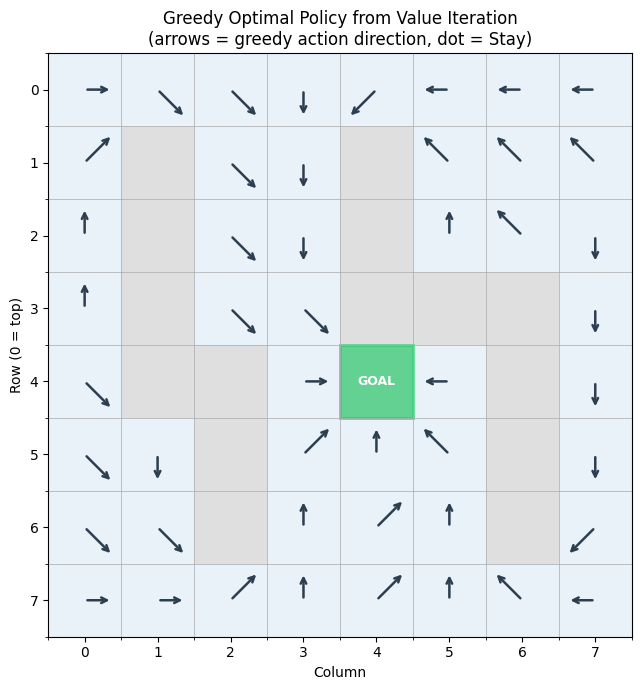

In [ ]:
# Q_vi from Cell 5 is shape (64, 9)
# ACTION_DELTAS[a] = (row_delta, col_delta)
# imshow origin='upper': row increases downward, so dy_plot = row_delta
greedy_policy = np.argmin(Q_vi, axis=1)

tr, tc = flat_to_rc(TERMINAL_STATE)

fig, ax = plt.subplots(figsize=(8, 7))

bg = np.full((GRID_SIZE, GRID_SIZE), np.nan)
for s in valid_states:
    r, c = flat_to_rc(s)
    bg[r, c] = 0.0

cmap_bg = plt.cm.Blues.copy()
cmap_bg.set_bad('#2d2d2d')
ax.imshow(bg, cmap=cmap_bg, origin='upper', vmin=-1, vmax=1, alpha=0.15)

goal_rect = mpatches.FancyBboxPatch(
    (tc - 0.5, tr - 0.5), 1, 1,
    boxstyle="square,pad=0.0",
    linewidth=2, edgecolor='#2ecc71', facecolor='#2ecc71', alpha=0.7
)
ax.add_patch(goal_rect)
ax.text(tc, tr, 'GOAL', ha='center', va='center',
        fontsize=9, color='white', fontweight='bold')

ARROW_SCALE = 0.38

for s in valid_states:
    r, c = flat_to_rc(s)
    a = greedy_policy[s]
    dr, dc = ACTION_DELTAS[a]
    # imshow origin='upper': x=col, y=row (row increases downward)
    dx_plot = dc
    dy_plot = dr   # row_delta > 0 means move down visually

    if a == 8:
        ax.plot(c, r, 'o', color='#e74c3c', markersize=6)
    else:
        ax.annotate(
            "",
            xy=(c + dx_plot * ARROW_SCALE, r + dy_plot * ARROW_SCALE),
            xytext=(c, r),
            arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.8)
        )

ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
ax.grid(which='minor', color='#aaaaaa', linewidth=0.5)
ax.set_xticks(range(GRID_SIZE))
ax.set_yticks(range(GRID_SIZE))
ax.set_xticklabels(range(GRID_SIZE))
ax.set_yticklabels(range(GRID_SIZE))
ax.set_xlabel("Column")
ax.set_ylabel("Row (0 = top)")
ax.set_title("Greedy Optimal Policy from Value Iteration\n"
             "(arrows = greedy action direction, dot = Stay)", fontsize=12)

plt.tight_layout()
plt.savefig('../report/figures/00/05_optimal_policy_arrows.png', dpi=150, bbox_inches='tight')
plt.show()

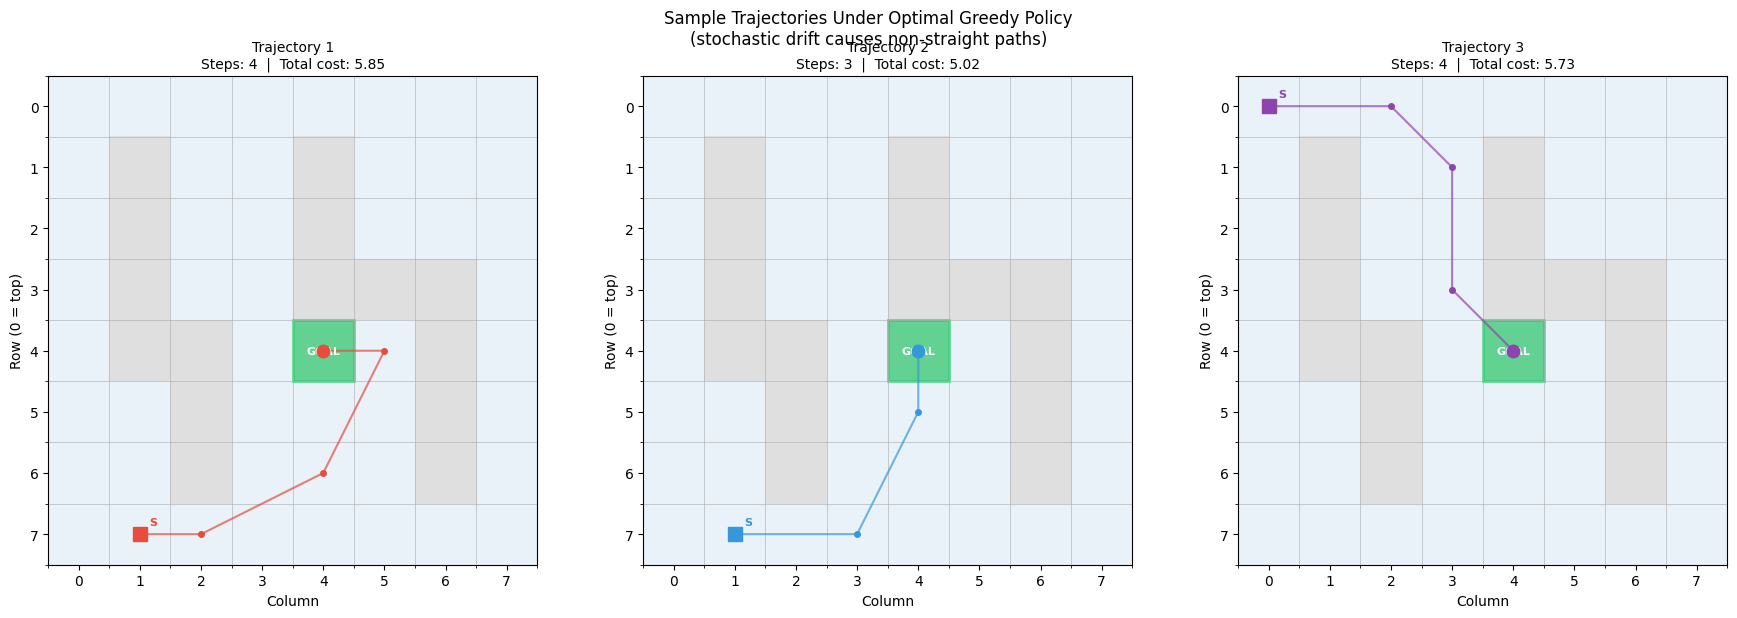

In [ ]:
N_TRAJECTORIES = 3
colors = ['#e74c3c', '#3498db', '#8e44ad']

fig, axes = plt.subplots(1, N_TRAJECTORIES, figsize=(18, 6))
tr, tc = flat_to_rc(TERMINAL_STATE)

for traj_idx in range(N_TRAJECTORIES):
    ax = axes[traj_idx]
    rng = np.random.default_rng(traj_idx * 7 + 13)
    env = GridWorldEnv(rng=rng)

    bg = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    for s in valid_states:
        r, c = flat_to_rc(s)
        bg[r, c] = 0.0

    cmap_bg = plt.cm.Blues.copy()
    cmap_bg.set_bad('#2d2d2d')
    ax.imshow(bg, cmap=cmap_bg, origin='upper', vmin=-1, vmax=1, alpha=0.15)

    ax.add_patch(mpatches.FancyBboxPatch(
        (tc - 0.5, tr - 0.5), 1, 1,
        boxstyle="square,pad=0.0",
        linewidth=2, edgecolor='#2ecc71', facecolor='#2ecc71', alpha=0.7
    ))
    ax.text(tc, tr, 'GOAL', ha='center', va='center',
            fontsize=8, color='white', fontweight='bold')

    obs  = env.reset()
    path = [(int(obs[0]), int(obs[1]))]
    total_cost = 0.0
    done  = False
    steps = 0

    while not done and steps < 200:
        s = int(obs[0]) * GRID_SIZE + int(obs[1])
        a = int(greedy_policy[s])
        obs, cost, done, _ = env.step(a)
        path.append((int(obs[0]), int(obs[1])))
        total_cost += cost
        steps += 1

    rows_p = [p[0] for p in path]
    cols_p = [p[1] for p in path]
    color  = colors[traj_idx]

    ax.plot(cols_p, rows_p, '-', color=color, linewidth=1.5, alpha=0.7)
    for i, (r, c) in enumerate(zip(rows_p, cols_p)):
        size = 4 if i not in (0, len(rows_p) - 1) else 9
        ax.plot(c, r, 'o', color=color, markersize=size, zorder=3)

    ax.plot(cols_p[0], rows_p[0], 's', color=color, markersize=10, zorder=4)
    ax.text(cols_p[0] + 0.15, rows_p[0] - 0.15, 'S',
            fontsize=8, color=color, fontweight='bold')

    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.set_xticklabels(range(GRID_SIZE))
    ax.set_yticklabels(range(GRID_SIZE))
    ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
    ax.grid(which='minor', color='#aaaaaa', linewidth=0.4)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row (0 = top)")
    ax.set_title(
        f"Trajectory {traj_idx + 1}\nSteps: {steps}  |  Total cost: {total_cost:.2f}",
        fontsize=10
    )

plt.suptitle("Sample Trajectories Under Optimal Greedy Policy\n"
             "(stochastic drift causes non-straight paths)", fontsize=12)
plt.tight_layout()
plt.savefig('../report/figures/00/06_sample_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

Probe state             : (0, 0)  flat=0
Probe action            : 2 (East)
N samples               : 5000
Mean cost               : 1.1456
Std cost                : 0.4268
Min cost                : -0.0907
Max cost                : 3.0884
Fraction with cost > 10 : 0.0000  (wall hits)
Fraction 1.5 < cost < 3.5: 0.1558  (drift events)


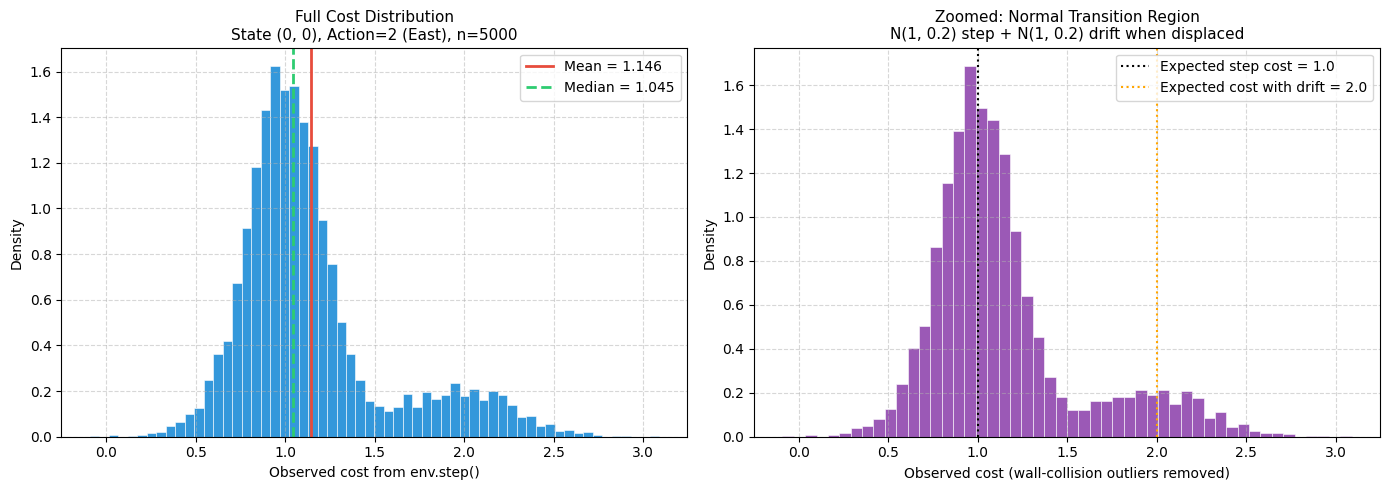

In [ ]:
PROBE_RC     = (0, 0)
PROBE_ACTION = 2          # East
N_SAMPLES    = 5000

rng_dist = np.random.default_rng(0)
env_dist = GridWorldEnv(rng=rng_dist)

costs_collected = []
for _ in range(N_SAMPLES):
    env_dist.reset_previous(PROBE_RC)
    _, cost, _, _ = env_dist.step(PROBE_ACTION)
    costs_collected.append(cost)

costs_arr = np.array(costs_collected)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(costs_arr, bins=60, color='#3498db', edgecolor='white',
        linewidth=0.4, density=True)
ax.axvline(costs_arr.mean(), color='#e74c3c', linewidth=2,
           label=f'Mean = {costs_arr.mean():.3f}')
ax.axvline(np.median(costs_arr), color='#2ecc71', linewidth=2, linestyle='--',
           label=f'Median = {np.median(costs_arr):.3f}')
ax.set_xlabel("Observed cost from env.step()")
ax.set_ylabel("Density")
ax.set_title(f"Full Cost Distribution\n"
             f"State {PROBE_RC}, Action={PROBE_ACTION} (East), n={N_SAMPLES}", fontsize=11)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[1]
normal_costs = costs_arr[costs_arr < 10]
ax.hist(normal_costs, bins=50, color='#9b59b6', edgecolor='white',
        linewidth=0.4, density=True)
ax.axvline(1.0, color='black', linewidth=1.5, linestyle=':',
           label='Expected step cost = 1.0')
ax.axvline(2.0, color='orange', linewidth=1.5, linestyle=':',
           label='Expected cost with drift = 2.0')
ax.set_xlabel("Observed cost (wall-collision outliers removed)")
ax.set_ylabel("Density")
ax.set_title("Zoomed: Normal Transition Region\n"
             "N(1, 0.2) step + N(1, 0.2) drift when displaced", fontsize=11)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

print(f"Probe state             : {PROBE_RC}  flat={PROBE_RC[0]*GRID_SIZE + PROBE_RC[1]}")
print(f"Probe action            : {PROBE_ACTION} (East)")
print(f"N samples               : {N_SAMPLES}")
print(f"Mean cost               : {costs_arr.mean():.4f}")
print(f"Std cost                : {costs_arr.std():.4f}")
print(f"Min cost                : {costs_arr.min():.4f}")
print(f"Max cost                : {costs_arr.max():.4f}")
print(f"Fraction with cost > 10 : {(costs_arr > 10).mean():.4f}  (wall hits)")
print(f"Fraction 1.5 < cost < 3.5: {((costs_arr > 1.5) & (costs_arr < 3.5)).mean():.4f}  (drift events)")

plt.tight_layout()
plt.savefig('../report/figures/00/07_cost_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

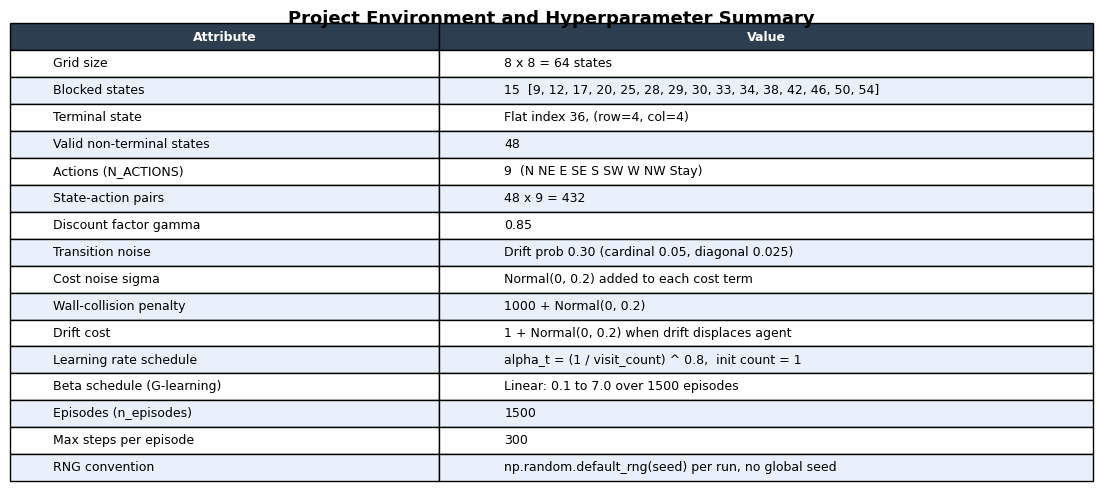


--- SUMMARY ---
  Grid size                                  8 x 8 = 64 states
  Blocked states                             15  [9, 12, 17, 20, 25, 28, 29, 30, 33, 34, 38, 42, 46, 50, 54]
  Terminal state                             Flat index 36, (row=4, col=4)
  Valid non-terminal states                  48
  Actions (N_ACTIONS)                        9  (N NE E SE S SW W NW Stay)
  State-action pairs                         48 x 9 = 432
  Discount factor gamma                      0.85
  Transition noise                           Drift prob 0.30 (cardinal 0.05, diagonal 0.025)
  Cost noise sigma                           Normal(0, 0.2) added to each cost term
  Wall-collision penalty                     1000 + Normal(0, 0.2)
  Drift cost                                 1 + Normal(0, 0.2) when drift displaces agent
  Learning rate schedule                     alpha_t = (1 / visit_count) ^ 0.8,  init count = 1
  Beta schedule (G-learning)                 Linear: 0.1 to 7.0 over 1500 

In [ ]:
rows_data = [
    ["Attribute",                    "Value"],
    ["Grid size",                    "8 x 8 = 64 states"],
    ["Blocked states",               f"{len(INV_ST)}  {sorted(INV_ST)}"],
    ["Terminal state",               f"Flat index {TERMINAL_STATE}, (row=4, col=4)"],
    ["Valid non-terminal states",    f"{len(valid_states)}"],
    ["Actions (N_ACTIONS)",          f"{N_ACTIONS}  (N NE E SE S SW W NW Stay)"],
    ["State-action pairs",           f"{len(valid_states)} x {N_ACTIONS} = {len(valid_states)*N_ACTIONS}"],
    ["Discount factor gamma",        f"{GAMMA}"],
    ["Transition noise",             "Drift prob 0.30 (cardinal 0.05, diagonal 0.025)"],
    ["Cost noise sigma",             "Normal(0, 0.2) added to each cost term"],
    ["Wall-collision penalty",       "1000 + Normal(0, 0.2)"],
    ["Drift cost",                   "1 + Normal(0, 0.2) when drift displaces agent"],
    ["Learning rate schedule",       "alpha_t = (1 / visit_count) ^ 0.8,  init count = 1"],
    ["Beta schedule (G-learning)",   "Linear: 0.1 to 7.0 over 1500 episodes"],
    ["Episodes (n_episodes)",        "1500"],
    ["Max steps per episode",        "300"],
    ["RNG convention",               "np.random.default_rng(seed) per run, no global seed"],
]

fig, ax = plt.subplots(figsize=(11, 5))
ax.axis('off')

table = ax.table(
    cellText=rows_data[1:],
    colLabels=rows_data[0],
    cellLoc='left',
    loc='center',
    colWidths=[0.38, 0.58]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.55)

for c in range(2):
    table[(0, c)].set_facecolor('#2c3e50')
    table[(0, c)].set_text_props(color='white', fontweight='bold')

for r in range(1, len(rows_data)):
    for c in range(2):
        table[(r, c)].set_facecolor('#eaf0fb' if r % 2 == 0 else 'white')

ax.set_title("Project Environment and Hyperparameter Summary",
             fontsize=13, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/figures/00/08_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- SUMMARY ---")
for row in rows_data[1:]:
    print(f"  {row[0]:<42} {row[1]}")